# 1. Carga del dataset validado

In [2]:
import pandas as pd

dataset = pd.read_csv(
    "../data/validation_dataset.csv",
    parse_dates=["DATE_TIME"]
)

# 2. Definición de niveles de severidad

In [3]:
threshold = 8.13 #umbral del notebook 4
low_limit = threshold
medium_limit = threshold * 2
high_limit = threshold * 3

print(f"Normal: ≤ {low_limit:.2f}%")
print(f"Leve: {low_limit:.2f}% - {medium_limit:.2f}%")
print(f"Moderada: {medium_limit:.2f}% - {high_limit:.2f}%")
print(f"Grave: > {high_limit:.2f}%")

Normal: ≤ 8.13%
Leve: 8.13% - 16.26%
Moderada: 16.26% - 24.39%
Grave: > 24.39%


In [4]:
def classify_anomaly(row):

    if not row["ANOMALY_DETECTED"]:
        return "NORMAL"

    elif row["ERROR_PCT_MOVING"] <= medium_limit:
        return "LOW"

    elif row["ERROR_PCT_MOVING"] <= high_limit:
        return "MEDIUM"

    else:
        return "HIGH"

# 3. Clasificación automática

In [5]:
dataset["ANOMALY_LEVEL"] = (
    dataset.apply(
        classify_anomaly,
        axis=1
    )
)

In [6]:
dataset[
    [
        "DATE_TIME",
        "ERROR_PCT_MOVING",
        "ANOMALY_DETECTED",
        "ANOMALY_LEVEL"
    ]
].head(20)

,DATE_TIME,ERROR_PCT_MOVING,ANOMALY_DETECTED,ANOMALY_LEVEL
0,2020-05-15 06:30:00,NaN,False,NORMAL
1,2020-05-15 06:45:00,NaN,False,NORMAL
2,2020-05-15 07:00:00,NaN,False,NORMAL
3,2020-05-15 07:15:00,1.742683,False,NORMAL
4,2020-05-15 07:30:00,1.519595,False,NORMAL
5,2020-05-15 07:45:00,1.286283,False,NORMAL
6,2020-05-15 08:00:00,0.554098,False,NORMAL
7,2020-05-15 08:15:00,0.407475,False,NORMAL
8,2020-05-15 08:30:00,0.946721,False,NORMAL
9,2020-05-15 08:45:00,1.468709,False,NORMAL


In [7]:
dataset["ANOMALY_LEVEL"].value_counts()

ANOMALY_LEVEL
NORMAL    1519
LOW         33
MEDIUM       2
Name: count, dtype: int64

In [8]:
dataset["ANOMALY_LEVEL"] = pd.Categorical(

    dataset["ANOMALY_LEVEL"],

    categories=[
        "NORMAL",
        "LOW",
        "MEDIUM",
        "HIGH"
    ],

    ordered=True

)

# 4. Agrupación de registros en eventos

In [22]:
dataset["TIME_DIFF"] = (
    dataset["DATE_TIME"].diff()
)

In [23]:
dataset["NEW_EVENT"] = (

    (dataset["ANOMALY_LEVEL"]
     !=
     dataset["ANOMALY_LEVEL"].shift())

    |

    (dataset["TIME_DIFF"]
     >
     pd.Timedelta(minutes=15))

)

In [24]:
dataset["EVENT_ID"] = (
    dataset["NEW_EVENT"]
    .cumsum()
)

In [25]:
dataset[
    [
        "DATE_TIME",
        "ANOMALY_LEVEL",
        "TIME_DIFF",
        "NEW_EVENT",
        "EVENT_ID"
    ]
].head(40)

,DATE_TIME,ANOMALY_LEVEL,TIME_DIFF,NEW_EVENT,EVENT_ID
0,2020-05-15 06:30:00,NORMAL,NaT,True,1
1,2020-05-15 06:45:00,NORMAL,0 days 00:15:00,False,1
2,2020-05-15 07:00:00,NORMAL,0 days 00:15:00,False,1
3,2020-05-15 07:15:00,NORMAL,0 days 00:15:00,False,1
4,2020-05-15 07:30:00,NORMAL,0 days 00:15:00,False,1
5,2020-05-15 07:45:00,NORMAL,0 days 00:15:00,False,1
6,2020-05-15 08:00:00,NORMAL,0 days 00:15:00,False,1
7,2020-05-15 08:15:00,NORMAL,0 days 00:15:00,False,1
8,2020-05-15 08:30:00,NORMAL,0 days 00:15:00,False,1
9,2020-05-15 08:45:00,NORMAL,0 days 00:15:00,False,1


In [26]:
events = dataset[
    dataset["ANOMALY_LEVEL"] != "NORMAL"
].copy()

In [27]:
event_summary = (

    events

    .groupby("EVENT_ID")

    .agg(

        START=("DATE_TIME","min"),

        END=("DATE_TIME","max"),

        LEVEL=("ANOMALY_LEVEL","first"),

        MAX_ERROR=("ERROR_PCT_MOVING","max"),

        MEAN_ERROR=("ERROR_PCT_MOVING","mean"),

        REGISTERS=("EVENT_ID","count")

    )

    .reset_index()

)

In [28]:
event_summary["DURATION"] = (

    event_summary["END"]

    -

    event_summary["START"]

    +

    pd.Timedelta(minutes=15)

)

In [29]:
event_summary["DURATION_MIN"] = (

    event_summary["DURATION"]

    .dt.total_seconds()

    /60

)

In [30]:
event_summary["DURATION_H"] = (

    event_summary["DURATION_MIN"]

    /60

)

In [31]:
event_summary

,EVENT_ID,START,END,LEVEL,MAX_ERROR,MEAN_ERROR,REGISTERS,DURATION,DURATION_MIN,DURATION_H
0,7,2020-05-19 16:45:00,2020-05-19 17:30:00,LOW,12.648895,11.205835,4,0 days 01:00:00,60.0,1.00
1,8,2020-05-20 06:30:00,2020-05-20 06:30:00,LOW,8.773825,8.773825,1,0 days 00:15:00,15.0,0.25
2,12,2020-05-21 08:15:00,2020-05-21 08:15:00,LOW,8.568934,8.568934,1,0 days 00:15:00,15.0,0.25
3,15,2020-05-22 11:30:00,2020-05-22 11:45:00,LOW,9.342082,8.844461,2,0 days 00:30:00,30.0,0.50
4,17,2020-05-22 12:15:00,2020-05-22 13:15:00,LOW,13.252110,11.325901,5,0 days 01:15:00,75.0,1.25
5,32,2020-06-03 17:45:00,2020-06-03 18:00:00,LOW,9.451020,8.864966,2,0 days 00:30:00,30.0,0.50
6,33,2020-06-04 06:30:00,2020-06-04 06:45:00,LOW,9.534725,9.416650,2,0 days 00:30:00,30.0,0.50
7,37,2020-06-06 07:00:00,2020-06-06 07:00:00,LOW,9.113426,9.113426,1,0 days 00:15:00,15.0,0.25
8,39,2020-06-06 11:45:00,2020-06-06 12:15:00,LOW,9.273232,8.611167,3,0 days 00:45:00,45.0,0.75
9,42,2020-06-07 13:00:00,2020-06-07 13:15:00,LOW,10.831506,9.759260,2,0 days 00:30:00,30.0,0.50


In [32]:
event_summary = (
    event_summary
    .sort_values("START")
    .reset_index(drop=True)
)

In [33]:
event_summary

,EVENT_ID,START,END,LEVEL,MAX_ERROR,MEAN_ERROR,REGISTERS,DURATION,DURATION_MIN,DURATION_H
0,7,2020-05-19 16:45:00,2020-05-19 17:30:00,LOW,12.648895,11.205835,4,0 days 01:00:00,60.0,1.00
1,8,2020-05-20 06:30:00,2020-05-20 06:30:00,LOW,8.773825,8.773825,1,0 days 00:15:00,15.0,0.25
2,12,2020-05-21 08:15:00,2020-05-21 08:15:00,LOW,8.568934,8.568934,1,0 days 00:15:00,15.0,0.25
3,15,2020-05-22 11:30:00,2020-05-22 11:45:00,LOW,9.342082,8.844461,2,0 days 00:30:00,30.0,0.50
4,17,2020-05-22 12:15:00,2020-05-22 13:15:00,LOW,13.252110,11.325901,5,0 days 01:15:00,75.0,1.25
5,32,2020-06-03 17:45:00,2020-06-03 18:00:00,LOW,9.451020,8.864966,2,0 days 00:30:00,30.0,0.50
6,33,2020-06-04 06:30:00,2020-06-04 06:45:00,LOW,9.534725,9.416650,2,0 days 00:30:00,30.0,0.50
7,37,2020-06-06 07:00:00,2020-06-06 07:00:00,LOW,9.113426,9.113426,1,0 days 00:15:00,15.0,0.25
8,39,2020-06-06 11:45:00,2020-06-06 12:15:00,LOW,9.273232,8.611167,3,0 days 00:45:00,45.0,0.75
9,42,2020-06-07 13:00:00,2020-06-07 13:15:00,LOW,10.831506,9.759260,2,0 days 00:30:00,30.0,0.50


# 5. Estadísticas

In [34]:
len(event_summary)

16

In [35]:
event_summary["LEVEL"].value_counts()

LEVEL
LOW       15
MEDIUM     1
Name: count, dtype: int64

In [36]:
event_summary.groupby("LEVEL")["DURATION_MIN"].mean()

LEVEL
LOW       33.0
MEDIUM    30.0
Name: DURATION_MIN, dtype: float64

In [37]:
event_summary.groupby("LEVEL")["MEAN_ERROR"].mean()

LEVEL
LOW        9.642681
MEDIUM    17.284087
Name: MEAN_ERROR, dtype: float64

In [38]:
event_summary.groupby("LEVEL")["MAX_ERROR"].max()

LEVEL
LOW       13.745626
MEDIUM    18.258205
Name: MAX_ERROR, dtype: float64

In [39]:
summary_table = (

    event_summary

    .groupby("LEVEL")

    .agg(

        EVENTS=("EVENT_ID", "count"),

        AVG_DURATION_MIN=("DURATION_MIN", "mean"),

        AVG_ERROR=("MEAN_ERROR", "mean"),

        MAX_ERROR=("MAX_ERROR", "max")

    )

    .round(2)

)

In [40]:
summary_table = summary_table.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

In [41]:
summary_table

,EVENTS,AVG_DURATION_MIN,AVG_ERROR,MAX_ERROR
LEVEL,,,,
LOW,15.0,33.0,9.64,13.75
MEDIUM,1.0,30.0,17.28,18.26
HIGH,NaN,NaN,NaN,NaN


In [42]:
summary_table.columns = [
    "Number of events",
    "Average duration (min)",
    "Average error (%)",
    "Maximum error (%)"
]

In [43]:
summary_table = summary_table.fillna("-")
summary_table

,Number of events,Average duration (min),Average error (%),Maximum error (%)
LEVEL,,,,
LOW,15.0,33.0,9.64,13.75
MEDIUM,1.0,30.0,17.28,18.26
HIGH,-,-,-,-


# 6. Dashboard

In [44]:
summary_table

,Number of events,Average duration (min),Average error (%),Maximum error (%)
LEVEL,,,,
LOW,15.0,33.0,9.64,13.75
MEDIUM,1.0,30.0,17.28,18.26
HIGH,-,-,-,-


In [45]:
import matplotlib.pyplot as plt

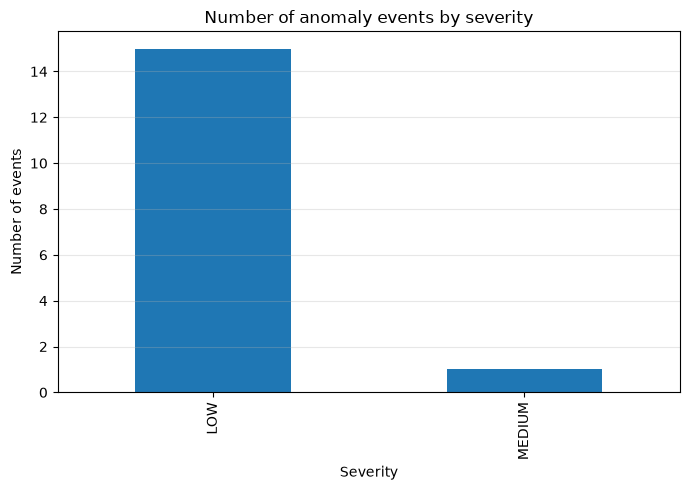

In [46]:
event_summary["LEVEL"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Number of anomaly events by severity")

plt.xlabel("Severity")

plt.ylabel("Number of events")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [47]:
severity_map = {

    "NORMAL":0,

    "LOW":1,

    "MEDIUM":2,

    "HIGH":3

}

dataset["SEVERITY_NUM"] = (
    dataset["ANOMALY_LEVEL"]
    .map(severity_map)
)

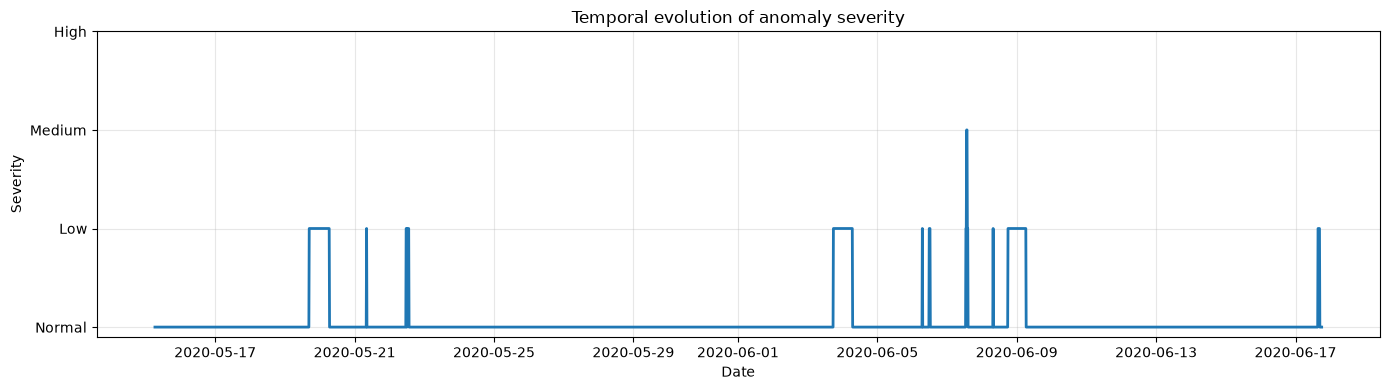

In [48]:
plt.figure(figsize=(14,4))

plt.plot(

    dataset["DATE_TIME"],

    dataset["SEVERITY_NUM"],

    linewidth=2

)

plt.yticks(

    [0,1,2,3],

    ["Normal","Low","Medium","High"]

)

plt.xlabel("Date")

plt.ylabel("Severity")

plt.title("Temporal evolution of anomaly severity")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [49]:
event_summary[
    [
        "START",
        "END",
        "LEVEL",
        "DURATION_MIN",
        "MAX_ERROR"
    ]
]

,START,END,LEVEL,DURATION_MIN,MAX_ERROR
0,2020-05-19 16:45:00,2020-05-19 17:30:00,LOW,60.0,12.648895
1,2020-05-20 06:30:00,2020-05-20 06:30:00,LOW,15.0,8.773825
2,2020-05-21 08:15:00,2020-05-21 08:15:00,LOW,15.0,8.568934
3,2020-05-22 11:30:00,2020-05-22 11:45:00,LOW,30.0,9.342082
4,2020-05-22 12:15:00,2020-05-22 13:15:00,LOW,75.0,13.252110
5,2020-06-03 17:45:00,2020-06-03 18:00:00,LOW,30.0,9.451020
6,2020-06-04 06:30:00,2020-06-04 06:45:00,LOW,30.0,9.534725
7,2020-06-06 07:00:00,2020-06-06 07:00:00,LOW,15.0,9.113426
8,2020-06-06 11:45:00,2020-06-06 12:15:00,LOW,45.0,9.273232
9,2020-06-07 13:00:00,2020-06-07 13:15:00,LOW,30.0,10.831506


In [50]:
plot_data = dataset[

    (dataset["DATE_TIME"] >= "2020-05-22 10:30:00")

    &

    (dataset["DATE_TIME"] <= "2020-05-22 13:30:00")

]

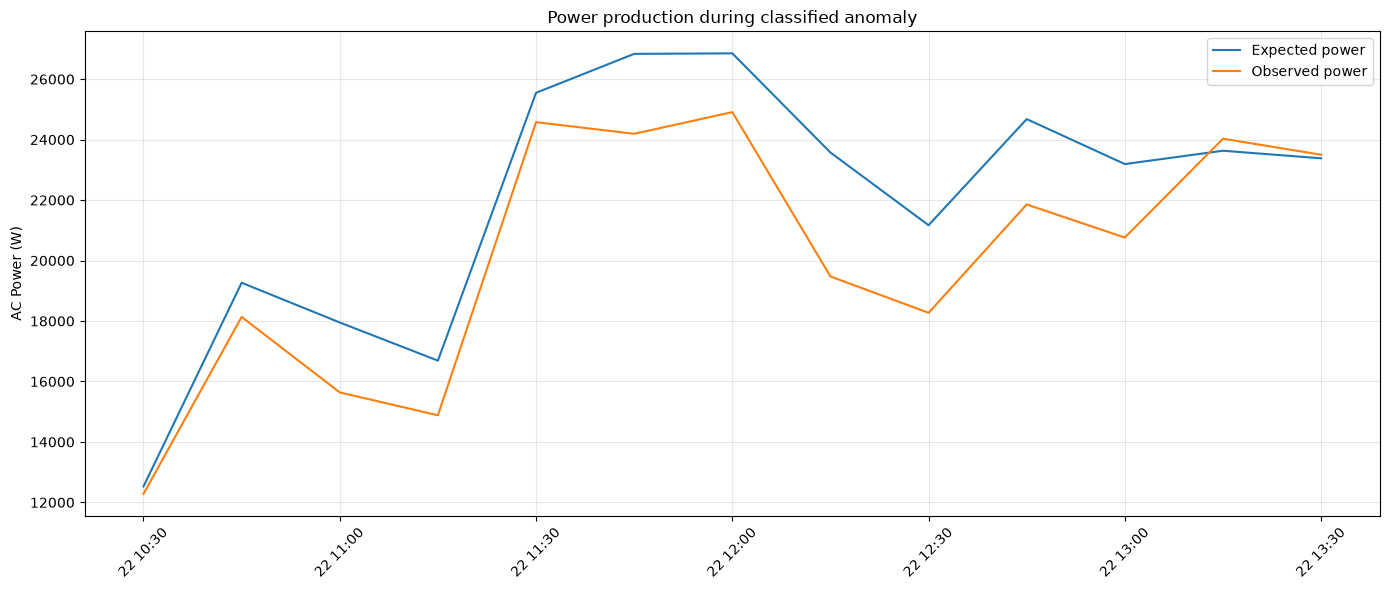

In [51]:
plt.figure(figsize=(14,6))

plt.plot(

    plot_data["DATE_TIME"],

    plot_data["EXPECTED_POWER"],

    label="Expected power"

)

plt.plot(

    plot_data["DATE_TIME"],

    plot_data["OBSERVED_POWER"],

    label="Observed power"

)

plt.xticks(rotation=45)

plt.ylabel("AC Power (W)")

plt.title("Power production during classified anomaly")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [53]:
event_summary.to_csv(
    "../results/anomaly_events.csv",
    index=False
)

In [54]:
summary_table.to_csv(
    "../results/anomaly_summary.csv"
)